import PIL.Image
import PIL.ImageDraw

# Load the image to get its dimensions
img = PIL.Image.open('input_file_0.jpeg')
width, height = img.size

# Identify the expression pedals area. They are roughly in the center, below the manuals and above the pedalboard.
# Let's define a rough box: [ymin, xmin, ymax, xmax] in normalized coordinates [0, 1000]
# From the image: pedals are roughly from y=450 to y=620, x=450 to x=620.
pedals_box = [460, 460, 615, 620]

# Convert normalized to pixel coordinates
def norm_to_pixel(norm_box, w, h):
    return [norm_box[0] * h / 1000, norm_box[1] * w / 1000, norm_box[2] * h / 1000, norm_box[3] * w / 1000]

pixel_box = norm_to_pixel(pedals_box, width, height)

# Crop and save
crop = img.crop((pixel_box[1], pixel_box[0], pixel_box[3], pixel_box[2]))
crop.save('expression_pedals.png')

# Display detection for confirmation
# [{box_2d: [464, 471, 608, 607], label: "expression pedals"}]



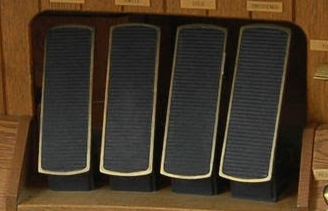

Based on the zoomed-in image, there are 4 expression pedals located in the center of the organ console, just above the pedalboard.


In [1]:
from google import genai
from google.genai import types
import requests
from PIL import Image
import io
from dotenv import load_dotenv
import os
load_dotenv()

image_path = "https://goo.gle/instrument-img"
image_bytes = requests.get(image_path).content
image = types.Part.from_bytes(data=image_bytes, mime_type="image/jpeg")

client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[
        image,
        "Zoom into the expression pedals and tell me how many pedals are there?"
    ],
    config=types.GenerateContentConfig(
        tools=[types.Tool(code_execution=types.ToolCodeExecution)]
    ),
)

for part in response.candidates[0].content.parts:
    if part.text is not None:
        print(part.text)
    if part.executable_code is not None:
        print(part.executable_code.code)
    if part.code_execution_result is not None:
        print(part.code_execution_result.output)
    if part.as_image() is not None:
        display(Image.open(io.BytesIO(part.as_image().image_bytes)))

KeyError: 'item_name'